In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [106]:
def get_data():

    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    data = pd.read_csv(url, header=None, sep=",", na_values="?")
    data.columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "disease_lvl"]

    data = data.dropna()
    return data

In [107]:
df = get_data()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,disease_lvl
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [108]:
df.disease_lvl.value_counts() # we will need softmax

disease_lvl
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64

In [ ]:
def get_data_loaders(data):

    X = data.drop("disease_lvl", axis=1)
    y = data["disease_lvl"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # scale pure numerical features and ordinal, but leave nominal without scaling
    # the nominal in this case don't need scaling since they are binary, otherwise we should apply one-hot encoding.
    # ordinal features are cp, restecg, slope, ca, thal (which are categorical but with an order)
    # nominal features are sex, fbs, exang (which are categorical without an order)

    numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
    ordinal_features = ["cp", "restecg", "slope", "ca", "thal"]
    nominal_features = ["sex", "fbs", "exang"] # binary in this case

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('ord', StandardScaler(), ordinal_features)
        ],
        remainder='passthrough' # This keeps the other columns as-is
    )

    X_train = preprocessor.fit_transform(X_train)
    X_test = preprocessor.transform(X_test)

    # convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train.values, dtype=torch.long) # for classification we need long
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test.values, dtype=torch.long) # for classification we need long

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    batch_size = 16
    train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_dl = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], shuffle=False)

    return train_dl, test_dl

In [110]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    batch_acc = []
    batch_loss = []
    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_acc_item = (output.argmax(dim=1) == y_batch).float().mean().item()
        batch_acc.append(batch_acc_item)
        batch_loss.append(loss.item())
        
    return np.mean(batch_acc), np.mean(batch_loss)

def train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)
    losses = np.zeros(epochs)
    
    for epoch in range(epochs):
        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_acc[epoch] = (output.argmax(dim=1) == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses

In [111]:
learning_rate = 0.0001
input_size = 13
hidden_size = 16
output_size = 5
epochs = 1000

model = SimpleNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
data = get_data()
train_dl, test_dl = get_data_loaders(data)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-2)
loss_fn = nn.CrossEntropyLoss()
train_acc, test_acc, losses = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs)

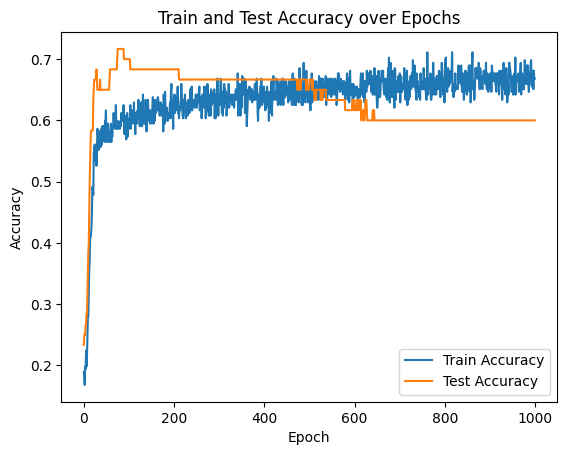

In [ ]:
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy over Epochs')
plt.legend()
plt.show()

# we have clear bias problem since the dataset we used was very small, but at least we have used
# dropout, mini-batches and L2 regularization to reduce overfitting.
# one solution to improve the performance would be to transform this into a binary problem, using 0 for non-deasease
# and higher than 0 as disease. Other solution could be to get a bigger dataset